---
# Analyse du Fichier de base
---

Essayons de comprendre quelles sont les features présentes et leur importance relative pour la popularité dans le dataset d'entraînement.

In [121]:
import numpy as np
import pandas as pd

X_train = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/X_train.csv", sep=";")
y_train = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/y_train.csv", sep=";")

In [3]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1348 non-null   int64  
 1   album            375 non-null    object 
 2   artist           1317 non-null   object 
 3   artists          1317 non-null   object 
 4   aspect_ratio     1348 non-null   float64
 5   channel          1348 non-null   object 
 6   description      1343 non-null   object 
 7   video_duration   1348 non-null   int64  
 8   format           1348 non-null   object 
 9   release_year     1348 non-null   int64  
 10  track            1322 non-null   object 
 11  uploader         1348 non-null   object 
 12  filepath         1348 non-null   object 
 13  download_timing  1348 non-null   object 
 14  uploader_short   1348 non-null   object 
 15  vid              1348 non-null   object 
 16  uid              1348 non-null   object 
dtypes: float64(1),

In [13]:
print(X_train.isnull().sum())

id                   0
album              973
artist              31
artists             31
aspect_ratio         0
channel              0
description          5
video_duration       0
format               0
release_year         0
track               26
uploader             0
filepath             0
download_timing      0
uploader_short       0
vid                  0
uid                  0
dtype: int64


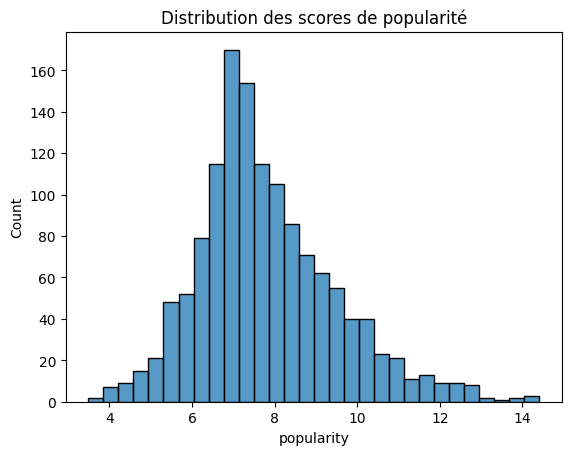

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
popularity = y_train['popularity']

plt.figure()
sns.histplot(popularity)
# plt.figure()
# sns.boxplot(popularity)
plt.title("Distribution des scores de popularité")
plt.show()

Regardons les premières corrélations utiles : 

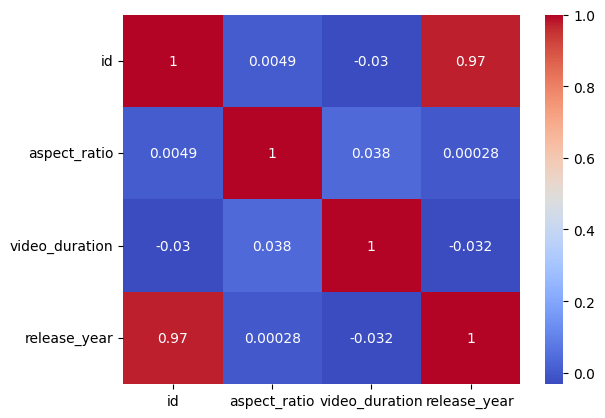

In [16]:
numeric_data = X_train.select_dtypes(include=[np.number])
plt.figure()
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm')
plt.show()

Nous remarquons que l'id de la vidéo doit correspondre à sa date de publication.

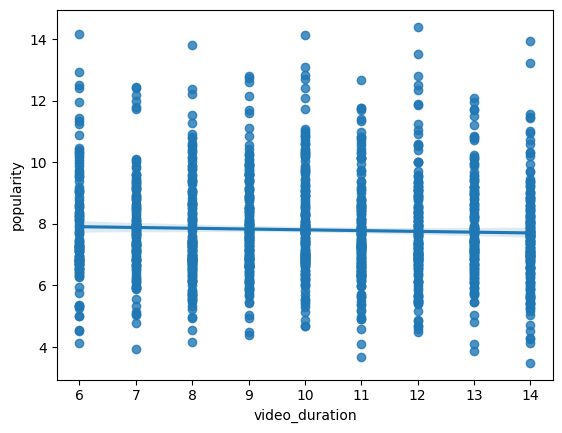

In [22]:
plt.figure()
sns.regplot(x= X_train['video_duration'], y=popularity)
plt.show()

Les corrélations entre les données numériques du dataset et le score de popularité sont assez faibles. 

### Traitement des métadonnées de type textuel

In [122]:
import pandas as pd
import re
import emoji

def extract_text_features(df, column_name='description'):
    # On s'assure que la colonne est bien du texte (remplace les NaN par du vide)
    text_data = df[column_name].fillna("")

    # 1. Longueur du texte (caractères)
    df['text_len'] = text_data.apply(len)

    # 2. Nombre de hashtags (on cherche les mots commençant par #)
    df['nb_hashtags'] = text_data.apply(lambda x: len(re.findall(r"#\w+", x)))

    # 3. Nombre d'émojis total
    df['nb_emojis'] = text_data.apply(lambda x: emoji.emoji_count(x))

    # 4. Feature binaire : Contient un point d'exclamation ? (Signe d'enthousiasme)
    df['has_exclamation'] = text_data.apply(lambda x: 1 if '!' in x else 0)

    # 5. Nombre de mentions (@user)
    df['nb_mentions'] = text_data.apply(lambda x: len(re.findall(r"@\w+", x)))
    df['hashtag_density']= df['nb_hashtags']/df['text_len']
    df['emoji_density'] = df['nb_emojis']/df['text_len']

    return df

# Utilisation
df = extract_text_features(X_train)

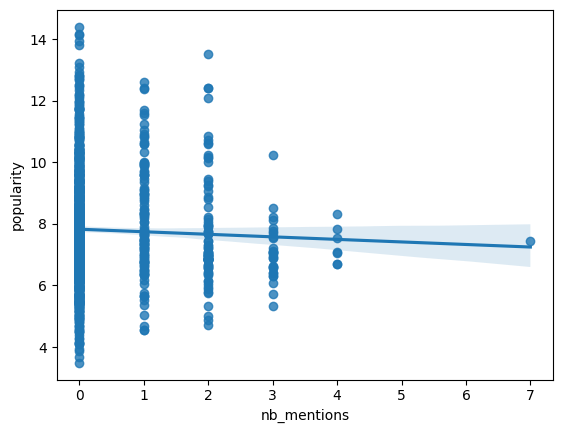

In [37]:
plt.figure()
sns.regplot(x=X_train['nb_mentions'], y=popularity)
plt.show()

In [40]:
# On définit la liste des features qu'on vient de créer + la cible
df_final = pd.concat([X_train, y_train], axis=1)
features_to_check = ['popularity', 'text_len', 'nb_hashtags', 'nb_emojis', 'has_exclamation', 'nb_mentions', 'hashtag_density']

# On calcule la corrélation uniquement pour ces colonnes
correlation_table = df_final[features_to_check].corr()

# On affiche surtout la colonne de la popularité, triée par importance
print("Corrélation avec le score de popularité :")
print(correlation_table['popularity'].sort_values(ascending=False))

Corrélation avec le score de popularité :
popularity         1.000000
hashtag_density    0.019937
has_exclamation    0.007505
nb_mentions       -0.036578
nb_emojis         -0.060471
nb_hashtags       -0.186817
text_len          -0.226033
Name: popularity, dtype: float64


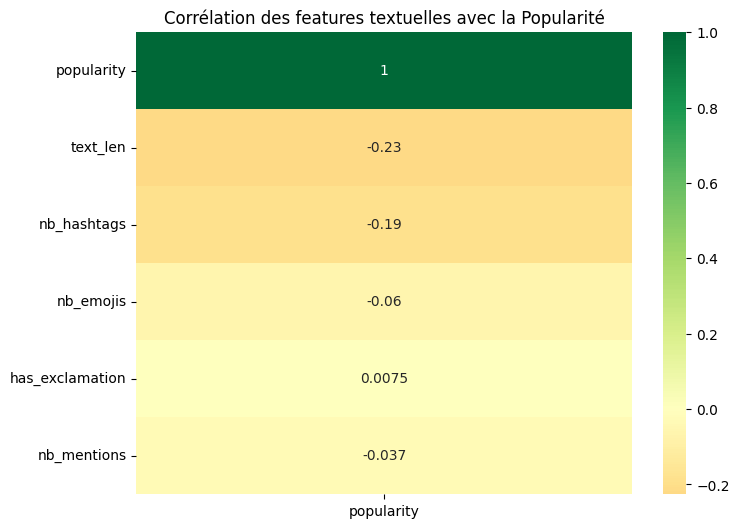

In [34]:
plt.figure(figsize=(8, 6))

# On génère la heatmap
sns.heatmap(correlation_table[['popularity']], 
            annot=True, 
            cmap='RdYlGn', 
            center=0)

plt.title('Corrélation des features textuelles avec la Popularité')
plt.show()

In [73]:
import langdetect


def clean_for_lang(text):
    # On enlève les émojis, les hashtags et les pseudos (@user)
    text = re.sub(r'#\w+|@\w+', '', text) # Enlève #hashtag et @mention
    text = re.sub(r'[^\w\s]', '', text)    # Enlève la ponctuation et émojis
    return text.strip()

import langid

# Liste des langues autorisées
ALLOWED_LANGS = ['fr', 'en', 'de', 'es', 'it']

# print(df_final['description'])

def get_lang_safe(text):
    # RÉFLEXE PRO : On force en string et on gère les cas vides ou non-texte
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return "unknown"
    
    cleaned = clean_for_lang(text)
    
    # Si après nettoyage il ne reste rien (ex: que des émojis)
    if len(cleaned.strip()) < 3:
        return "unknown"
    
    try:
        predictions = langid.rank(cleaned)
        for lang, score in predictions:
            if lang in ALLOWED_LANGS:
                return lang
    except Exception:
        # En hackathon, on ne veut pas que le script s'arrête pour une erreur d'encodage
        return "unknown"
            
    return "unknown"

# Et on applique
# df['lang'] = df['description'].apply(get_lang_safe)

df_final['lang'] = df_final['description'].apply(get_lang_safe)


In [74]:
print(df_final['lang'])

0       en
1       en
2       en
3       en
4       en
        ..
1343    es
1344    es
1345    es
1346    es
1347    es
Name: lang, Length: 1348, dtype: object


Maintenant que la langue est extraite, essayons d'en faire quelque chose.

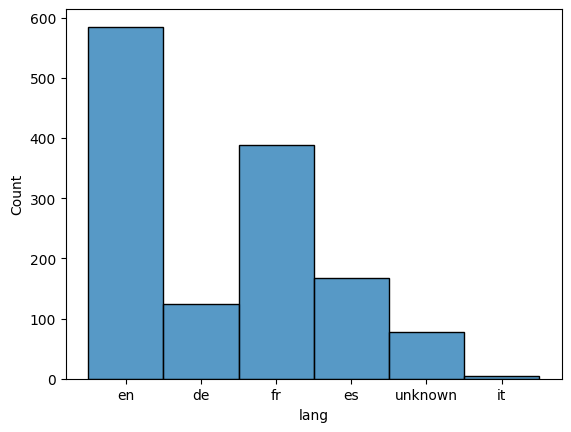

In [75]:
plt.figure()
sns.histplot(df_final, x='lang')
plt.show()

**One hot encoding des langues** 

In [77]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. Création de l'instance
# sparse_output=False : pour obtenir un tableau numpy classique (plus facile à lire)
# handle_unknown='ignore' : si une langue bizarre arrive plus tard, il met des 0 partout au lieu de crash
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Entraînement (fit) et transformation (transform)
# Note : fit_transform attend un tableau 2D, d'où le double crochet [['lang']]
lang_encoded = encoder.fit_transform(df_final[['lang']])

# 3. Récupération des noms de colonnes (ex: lang_fr, lang_en...)
column_names = encoder.get_feature_names_out(['lang'])

# 4. Création d'un DataFrame avec ces nouvelles colonnes
df_langs = pd.DataFrame(lang_encoded, columns=column_names, index=df.index)

# On concatène horizontalement
df_final = pd.concat([df_final, df_langs], axis=1)

# Optionnel : on supprime l'ancienne colonne texte 'lang' qui ne sert plus au modèle
df_final = df_final.drop('lang', axis=1)

# On regarde la corrélation spécifiquement pour les nouvelles colonnes de langue
correlations = df_final[list(column_names) + ['popularity']].corr()
print(correlations['popularity'].sort_values(ascending=False))

popularity      1.000000
lang_fr         0.223747
lang_unknown    0.035872
lang_es         0.014043
lang_it        -0.036884
lang_de        -0.080343
lang_en        -0.179332
Name: popularity, dtype: float64


Nous allons maintenant tenter une première exploitation des résultats:

In [ ]:
print(df_final.columns)
df_ml = X_train
def prepare_dataset(df_final):
    df_ml = df_final.select_dtypes(include=[np.number])
    df_ml = df_ml.drop(['id'], axis=1)
    print(df_ml.columns)
    if df_ml.isnull().sum().any():
        print("Attention : NaNs détectés, remplacement par la médiane.")
        df_ml = df_ml.fillna(df_ml.median())
    return df_ml



Index(['id', 'album', 'artist', 'artists', 'aspect_ratio', 'channel',
       'description', 'video_duration', 'format', 'release_year', 'track',
       'uploader', 'filepath', 'download_timing', 'uploader_short', 'vid',
       'uid', 'text_len', 'nb_hashtags', 'nb_emojis', 'has_exclamation',
       'nb_mentions', 'hashtag_density', 'lang_de', 'lang_en', 'lang_es',
       'lang_fr', 'lang_it', 'lang_unknown'],
      dtype='object')


In [86]:
if df_ml.isnull().sum().any():
    print("Attention : NaNs détectés, remplacement par la médiane.")
    df_ml = df_ml.fillna(df_ml.median())

Attention : NaNs détectés, remplacement par la médiane.


In [ ]:
df_ml.to_csv('train_features_clean.csv', index=False)
print(f"Fichier prêt ! Dimensions : {df_ml.shape}")

Fichier prêt ! Dimensions : (1348, 15)


In [101]:
df_test = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/X_test.csv", sep=";")

df_test = extract_text_features(df_test, 'description')




In [102]:
print(df_test.columns)

Index(['id', 'album', 'artist', 'artists', 'aspect_ratio', 'channel',
       'description', 'video_duration', 'format', 'release_year', 'track',
       'uploader', 'filepath', 'download_timing', 'uploader_short', 'vid',
       'uid', 'text_len', 'nb_hashtags', 'nb_emojis', 'has_exclamation',
       'nb_mentions', 'hashtag_density'],
      dtype='object')


In [103]:
df_test['lang'] = df_test['description'].apply(get_lang_safe)

In [104]:
print(df_test.columns)

Index(['id', 'album', 'artist', 'artists', 'aspect_ratio', 'channel',
       'description', 'video_duration', 'format', 'release_year', 'track',
       'uploader', 'filepath', 'download_timing', 'uploader_short', 'vid',
       'uid', 'text_len', 'nb_hashtags', 'nb_emojis', 'has_exclamation',
       'nb_mentions', 'hashtag_density', 'lang'],
      dtype='object')


In [105]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# 2. Entraînement (fit) et transformation (transform)
# Note : fit_transform attend un tableau 2D, d'où le double crochet [['lang']]
lang_encoded = encoder.fit_transform(df_test[['lang']])

# 3. Récupération des noms de colonnes (ex: lang_fr, lang_en...)
column_names = encoder.get_feature_names_out(['lang'])

# 4. Création d'un DataFrame avec ces nouvelles colonnes
df_langs = pd.DataFrame(lang_encoded, columns=column_names, index=df_test.index)

# On concatène horizontalement
df_test = pd.concat([df_test, df_langs], axis=1)

# Optionnel : on supprime l'ancienne colonne texte 'lang' qui ne sert plus au modèle
df_test = df_test.drop('lang', axis=1)

In [106]:
print(df_test.columns)

Index(['id', 'album', 'artist', 'artists', 'aspect_ratio', 'channel',
       'description', 'video_duration', 'format', 'release_year', 'track',
       'uploader', 'filepath', 'download_timing', 'uploader_short', 'vid',
       'uid', 'text_len', 'nb_hashtags', 'nb_emojis', 'has_exclamation',
       'nb_mentions', 'hashtag_density', 'lang_de', 'lang_en', 'lang_es',
       'lang_fr', 'lang_it', 'lang_unknown'],
      dtype='object')


In [111]:
df_test_ml = prepare_dataset(df_test)

Index(['aspect_ratio', 'video_duration', 'release_year', 'text_len',
       'nb_hashtags', 'nb_emojis', 'has_exclamation', 'nb_mentions',
       'hashtag_density', 'lang_de', 'lang_en', 'lang_es', 'lang_fr',
       'lang_it', 'lang_unknown'],
      dtype='object')
Attention : NaNs détectés, remplacement par la médiane.


In [112]:
df_test_ml.to_csv('test_features.csv', index= False)

Essayons de faire un LightBM : 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 1078, number of used features: 14
[LightGBM] [Info] Start training from score 7.837476
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[28]	valid_0's l2: 2.17455

--- RÉSULTATS SUR LE TEST LOCAL ---
RMSE : 1.47
R²   : 0.1807


/tmp/ipykernel_640091/1876624083.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance.head(15), palette='viridis')


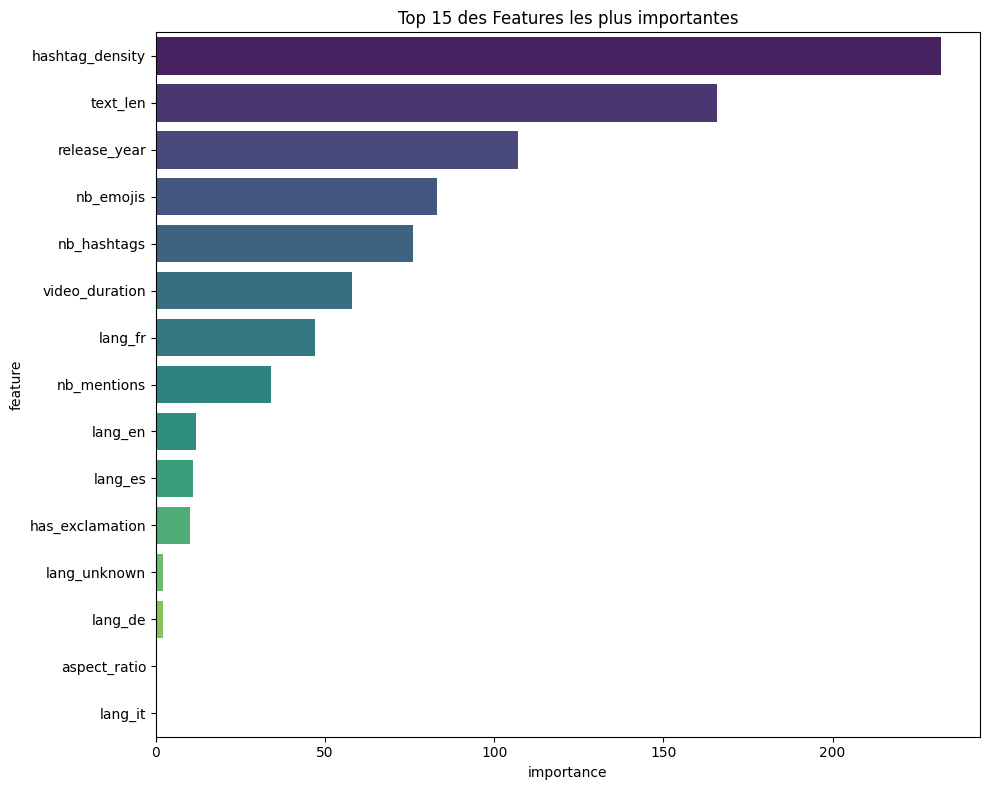

In [119]:
import pandas as pd
import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Chargement du dataset de base
df = pd.read_csv('train_features_clean.csv')
y_train = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/y_train.csv", sep=";")

# 2. Séparation Features (X) et Cible (y)
X = df
y = y_train['popularity']

# 3. Création du Train et du Test local (80% / 20%)
# random_state=42 permet d'avoir toujours les mêmes résultats pour comparer tes progrès
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Configuration et Entraînement du LightGBM
model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    random_state=42
)

# On utilise le X_test local comme set de validation pour l'early stopping
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=100)]
)

# 5. Prédictions et Métriques
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"\n--- RÉSULTATS SUR LE TEST LOCAL ---")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# 6. Graphe d'importance des Features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(ascending=False, by='importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15), palette='viridis')
plt.title('Top 15 des Features les plus importantes')
plt.tight_layout()
plt.show()


RMSE Finale : 1.56


/tmp/ipykernel_640091/7116731.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance.head(15), palette='magma')


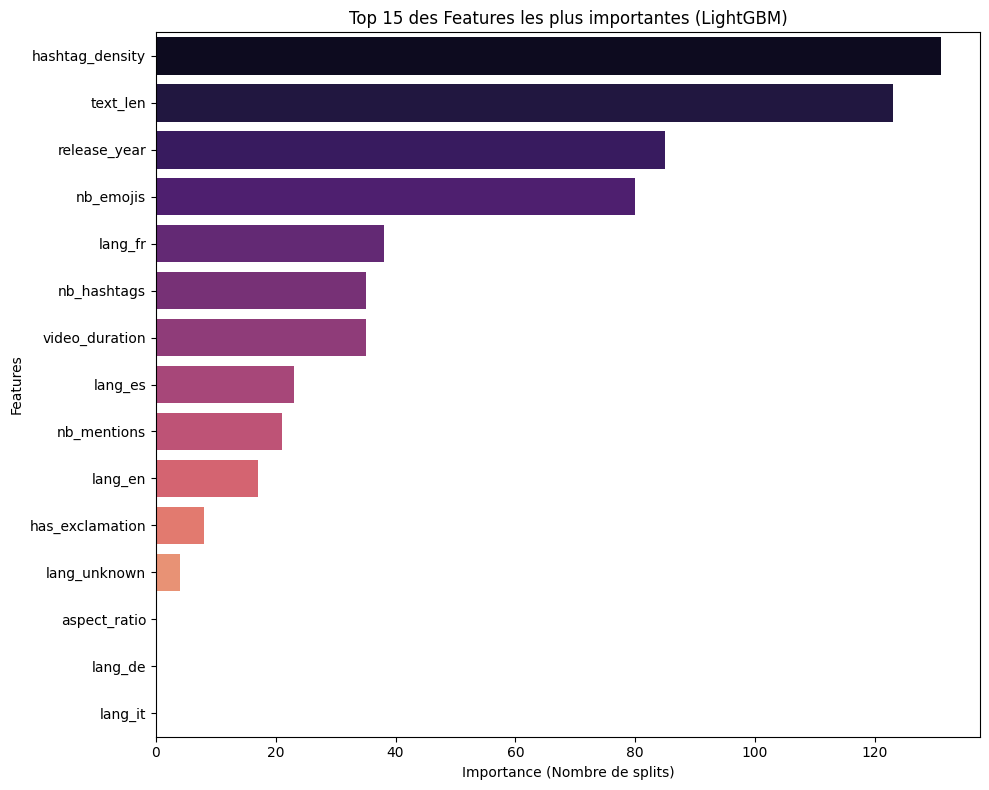

In [115]:
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Calcul de la RMSE ---
# On compare les vraies valeurs (y) aux prédictions Out-Of-Fold (oof_preds)
rmse_score = np.sqrt(mean_squared_error(y, oof_preds))
print(f"\nRMSE Finale : {rmse_score:.2f}")

# --- 2. Visualisation des Features les plus importantes ---
# On récupère l'importance des features du dernier modèle entraîné
# (Note : 'split' compte le nombre de fois qu'une feature est utilisée)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(ascending=False, by='importance')

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15), palette='magma')
plt.title('Top 15 des Features les plus importantes (LightGBM)')
plt.xlabel('Importance (Nombre de splits)')
plt.ylabel('Features')
plt.tight_layout() # Pour éviter que les noms soient coupés
plt.show()

In [ ]:
# On définit des thèmes transversaux (Ski / Montagne)
themes = {
    'feat_meteo': ['soleil', 'sun', 'sky', 'ciel', 'bluebird', 'poudreuse', 'powder', 'snow', 'neige'],
    'feat_action': ['ski', 'jump', 'vitesse', 'speed', 'freeride', 'backflip', 'shred', 'sendit'],
    'feat_engagement': ['abonne', 'follow', 'tag', 'friend', 'ami', 'partage', 'share', 'comment'],
    'feat_lieu': ['station', 'resort', 'alpes', 'alps', 'montagne', 'mountain', 'piste']
}

def apply_multilingual_themes(df):
    # On met tout en minuscule pour ne pas rater "Snow" vs "snow"
    desc_clean = df['description'].str.lower().fillna("")
    
    for theme, keywords in themes.items():
        # On crée une colonne binaire : 1 si un des mots du thème est présent
        df[theme] = desc_clean.apply(lambda x: 1 if any(word in x for word in keywords) else 0)
    
    return df

df = apply_multilingual_themes(df)

---
# Résumé global
---

In [128]:
import pandas as pd
import numpy as np
import re
import emoji
import langid
from sklearn.preprocessing import OneHotEncoder

# --- CONFIGURATION DES DICTIONNAIRES MULTILINGUES ---
# On regroupe les mots par intention, peu importe la langue
DICT_THEMES = {
    'feat_meteo': [
        'soleil', 'sun', 'sonne', 'sol', 'ciel', 'sky', 'himmel', 'poudreuse', 
        'powder', 'snow', 'neige', 'schnee', 'nieve', 'bluebird', '❄️', '☀️', '🏔️'
    ],
    'feat_cta': [
        'follow', 'abonne', 'like', 'aime', 'comment', 'partage', 'share', 
        'teilen', 'tag', 'ami', 'friend', 'freund', '👇', '❤️', '💬', '👥'
    ],
    'feat_action': [
        'ski', 'skifahren', 'freeride', 'jump', 'saut', 'vitesse', 'speed', 
        'backflip', 'shred', 'sendit', '⛷️', '🏂', '🔥', '🚀', '💯'
    ]
}


def clean_for_lang(text):
    # On enlève les émojis, les hashtags et les pseudos (@user)
    text = re.sub(r'#\w+|@\w+', '', text) # Enlève #hashtag et @mention
    text = re.sub(r'[^\w\s]', '', text)    # Enlève la ponctuation et émojis
    return text.strip()

import langid

# Liste des langues autorisées
ALLOWED_LANGS = ['fr', 'en', 'de', 'es', 'it']

# print(df_final['description'])

def get_lang_safe(text):
    # RÉFLEXE PRO : On force en string et on gère les cas vides ou non-texte
    if not isinstance(text, str) or pd.isna(text) or text.strip() == "":
        return "unknown"
    
    cleaned = clean_for_lang(text)
    
    # Si après nettoyage il ne reste rien (ex: que des émojis)
    if len(cleaned.strip()) < 3:
        return "unknown"
    
    try:
        predictions = langid.rank(cleaned)
        for lang, score in predictions:
            if lang in ALLOWED_LANGS:
                return lang
    except Exception:
        # En hackathon, on ne veut pas que le script s'arrête pour une erreur d'encodage
        return "unknown"
            
    return "unknown"
# def clean_text_basic(text):
#     """Nettoie légèrement le texte pour la détection de langue."""
#     if not isinstance(text, str): return ""
#     # On garde les mots mais on enlève la ponctuation pure pour aider langid
#     text = re.sub(r'[^\w\s#@]', '', text)
#     return text.strip()

# def get_lang_safe(text):
#     """Détecte la langue parmi une liste restreinte."""
#     cleaned = clean_text_basic(text)
#     if len(cleaned) < 5: # Trop court pour être fiable
#         return "unknown"
#     try:
#         # On demande à langid de classer parmi les langues autorisées
#         langid.set_langs(ALLOWED_LANGS)
#         lang, score = langid.classify(cleaned)
#         return lang
#     except:
#         return "unknown"

def process_tiktok_features(df):
    """
    Charge le CSV, extrait les features et retourne un DataFrame prêt pour le ML.
    """
    # 1. Chargement
    
    # Sécurité : on s'assure que la description est du texte
    df['description'] = df['description'].fillna("").astype(str)
    desc_lower = df['description'].str.lower()

    # 2. Features de base (Comptages)
    df['text_len'] = df['description'].apply(len)
    df['nb_hashtags'] = df['description'].apply(lambda x: len(re.findall(r"#\w+", x)))
    df['nb_emojis'] = df['description'].apply(lambda x: emoji.emoji_count(x))
    df['nb_mentions'] = df['description'].apply(lambda x: len(re.findall(r"@\w+", x)))

    # 3. Features de Densité (Réflexes d'analyste)
    # Le +1 évite la division par zéro pour les descriptions vides
    df['hashtag_density'] = df['nb_hashtags'] / (df['text_len'] + 1)
    df['emoji_density'] = df['nb_emojis'] / (df['text_len'] + 1)

    # 4. Approche Dictionnaire (Multilingue + Hashtags)
    # Comme hashtags et mots sont dans la même string, str.contains suffit
    for feat_name, keywords in DICT_THEMES.items():
        # On crée un pattern regex pour chercher tous les mots du dictionnaire d'un coup
        # \b assure qu'on cherche le mot entier (pas 'ski' dans 'skier')
        pattern = '|'.join([re.escape(word) for word in keywords])
        df[feat_name] = desc_lower.str.contains(pattern, regex=True).astype(int)

    # 5. Détection de la Langue
    df['lang_detected'] = df['description'].apply(get_lang_safe)

    # 6. One-Hot Encoding de la Langue (Méthode Pro)
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    lang_encoded = encoder.fit_transform(df[['lang_detected']])
    lang_cols = [f"lang_{c}" for c in encoder.get_feature_names_out(['lang_detected'])]
    df_lang_encoded = pd.DataFrame(lang_encoded, columns=lang_cols, index=df.index)

    # 7. Assemblage Final
    # On concatène et on ne garde que les colonnes numériques
    df_final = pd.concat([df, df_lang_encoded], axis=1)
    
    # On ne garde que les colonnes utiles pour le modèle (numériques)
    # On exclut les colonnes originales de texte et l'ID si présent
    cols_to_drop = ['description', 'lang_detected']
    # On ajoute video_id ou d'autres colonnes texte si elles existent dans ton CSV
    existing_drops = [c for c in cols_to_drop if c in df_final.columns]
    df_ml = df_final.select_dtypes(include=[np.number]).drop(columns=existing_drops, errors='ignore')

    return df_ml


X_train = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/X_train.csv", sep=";")
df_ready = process_tiktok_features(X_train)
print(f"Features générées : {df_ready.columns.tolist()}")
df_ready.to_csv('train_features_ready.csv', index=False)
# --- EXEMPLE D'UTILISATION ---
# if __name__ == "__main__":
#     df_ready = process_tiktok_features('train.csv')
#     print(f"Features générées : {df_ready.columns.tolist()}")
#     df_ready.to_csv('train_features_ready.csv', index=False)

Features générées : ['id', 'aspect_ratio', 'video_duration', 'release_year', 'text_len', 'nb_hashtags', 'nb_emojis', 'nb_mentions', 'hashtag_density', 'emoji_density', 'feat_meteo', 'feat_cta', 'feat_action', 'lang_lang_detected_de', 'lang_lang_detected_en', 'lang_lang_detected_es', 'lang_lang_detected_fr', 'lang_lang_detected_it', 'lang_lang_detected_unknown']


In [130]:
X_test = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/X_test.csv", sep=";")
df_test_ready = process_tiktok_features(X_test)
print(f"Features générées : {df_test_ready.columns.tolist()}")
df_test_ready.to_csv('test_features_ready.csv', index=False)

Features générées : ['id', 'aspect_ratio', 'video_duration', 'release_year', 'text_len', 'nb_hashtags', 'nb_emojis', 'nb_mentions', 'hashtag_density', 'emoji_density', 'feat_meteo', 'feat_cta', 'feat_action', 'lang_lang_detected_de', 'lang_lang_detected_en', 'lang_lang_detected_es', 'lang_lang_detected_fr', 'lang_lang_detected_it', 'lang_lang_detected_unknown']


---
# Analyse du sentiment des descriptions
---


In [ ]:
import pandas as pd
import numpy as np
import re
import langid
from textblob import TextBlob
from textblob_fr import PatternTagger, PatternAnalyzer

# --- Configuration pour la détection de langue ---
ALLOWED_LANGS = ['fr', 'en', 'de', 'es']

# --- Dictionnaire de traduction d'émojis pour le sentiment ---
EMOJI_TO_TEXT = {
    "🔥": " génial ",
    "❤️": " j'adore ",
    "😍": " magnifique ",
    "❄️": " neige ",
    "⛷️": " ski ",
    "🚀": " rapide ",
    "💀": " incroyable ",
    "😂": " rire ",
    "🥶": " froid ",
    "⚠️": " attention ",
    "❌": " mauvais "
}

def translate_emojis(text):
    """Remplace les émojis par des mots-clés de sentiment."""
    if not isinstance(text, str):
        return ""
    for emoji, replacement in EMOJI_TO_TEXT.items():
        text = text.replace(emoji, replacement)
    return text

def get_lang_on_the_fly(text):
    """Détecte la langue si elle n'est pas déjà présente dans le DataFrame."""
    if not isinstance(text, str) or len(text) < 5:
        return "en" # Fallback par défaut
    try:
        langid.set_langs(ALLOWED_LANGS)
        lang, _ = langid.classify(text)
        return lang
    except:
        return "en"

def get_sentiment_score(text, lang):
    """
    Calcule le score de sentiment après avoir 'traduit' les émojis.
    """
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    
    # Étape d'amélioration : on injecte le sens des émojis dans le texte
    text_with_emojis = translate_emojis(text)
    
    try:
        if lang == 'fr':
            # Analyseur lexical français
            return TextBlob(text_with_emojis, pos_tagger=PatternTagger(), analyzer=PatternAnalyzer()).sentiment[0]
        else:
            # Analyseur lexical standard (anglais et autres)
            return TextBlob(text_with_emojis).sentiment.polarity
    except Exception:
        return 0.0

def process_sentiment_only(df):
    """
    Fonction principale dédiée uniquement à l'analyse de sentiment.
    Elle gère l'absence de la colonne 'lang_detected' en la recréant si nécessaire.
    """
    if 'description' not in df.columns:
        print("Erreur : La colonne 'description' est absente. Impossible de calculer le sentiment.")
        return df

    # --- GESTION DE LA LANGUE MANQUANTE ---
    if 'lang_detected' not in df.columns:
        print("Colonne 'lang_detected' manquante. Redétection en cours...")
        df['lang_detected'] = df['description'].apply(get_lang_on_the_fly)

    print("Traitement du sentiment (avec support émojis)...")
    
    # Calcul du score
    df['sentiment_score'] = [
        get_sentiment_score(t, l) for t, l in zip(df['description'], df['lang_detected'])
    ]
    
    # Feature d'intensité : peu importe si c'est positif ou négatif, est-ce fort ?
    df['sentiment_absolute'] = df['sentiment_score'].abs()
    
    # Feature binaire : la description est-elle positive ?
    df['is_positive'] = (df['sentiment_score'] > 0.1).astype(int)

    return df

# --- Exemple d'usage ---
df = pd.read_csv(r"/home/adrie/SDD/hackathon/sia-predicting-short-form-video-popularity/X_train.csv", sep=";")
df = process_sentiment_only(df)


Colonne 'lang_detected' manquante. Redétection en cours...
Traitement du sentiment (avec support émojis)...
                    id album               artist                  artists  \
0  7602656035161050390   NaN         Urhov Bogdan         ['Urhov Bogdan']   
1  7590718903144287510   NaN            LykTraffx            ['LykTraffx']   
2  7571821778746592534   NaN               ALTÉGO               ['ALTÉGO']   
3  7569927329154190614   NaN                 Raye                 ['Raye']   
4  7566270741134462230   NaN  músicas e traduções  ['músicas e traduções']   

   aspect_ratio         channel  \
0          0.56  Davos Klosters   
1          0.56  Davos Klosters   
2          0.56  Davos Klosters   
3          0.56  Davos Klosters   
4          0.56  Davos Klosters   

                                         description  video_duration  \
0  you dream you 🥹 #davosklosters #skiing #mounta...              13   
1  already missing this again 🥹 #spenglercup #dav...              12

In [ ]:
print(df['sentiment_score'].iloc[:100])
df = process_tiktok_features(df)


0     0.00000
1    -0.20000
2     0.00000
3     0.00000
4     0.00000
       ...   
95    0.33125
96    0.00000
97    0.00000
98    0.00000
99    0.00000
Name: sentiment_score, Length: 100, dtype: float64


In [ ]:
print(df.columns)

Index(['id', 'aspect_ratio', 'video_duration', 'release_year',
       'sentiment_score', 'sentiment_absolute', 'is_positive', 'text_len',
       'nb_hashtags', 'nb_emojis', 'nb_mentions', 'hashtag_density',
       'emoji_density', 'feat_meteo', 'feat_cta', 'feat_action',
       'lang_lang_detected_de', 'lang_lang_detected_en',
       'lang_lang_detected_es', 'lang_lang_detected_fr',
       'lang_lang_detected_unknown'],
      dtype='object')


In [ ]:

df_concat = pd.concat([df, y_train], axis=1)
print(df_concat.columns)
df_concat = df_concat.drop(['id', 'ID'], axis=1)

Index(['id', 'aspect_ratio', 'video_duration', 'release_year',
       'sentiment_score', 'sentiment_absolute', 'is_positive', 'text_len',
       'nb_hashtags', 'nb_emojis', 'nb_mentions', 'hashtag_density',
       'emoji_density', 'feat_meteo', 'feat_cta', 'feat_action',
       'lang_lang_detected_de', 'lang_lang_detected_en',
       'lang_lang_detected_es', 'lang_lang_detected_fr',
       'lang_lang_detected_unknown', 'ID', 'popularity'],
      dtype='object')


In [148]:
corr = df_concat.corr(method='pearson')
print(corr)

                            aspect_ratio  video_duration  release_year  \
aspect_ratio                    1.000000        0.037742      0.000284   
video_duration                  0.037742        1.000000     -0.031635   
release_year                    0.000284       -0.031635      1.000000   
sentiment_score                -0.016459        0.036527      0.031077   
sentiment_absolute             -0.014842        0.039595      0.010201   
is_positive                    -0.016437        0.025199      0.057328   
text_len                        0.008957        0.082520      0.207075   
nb_hashtags                    -0.015614        0.024134     -0.197319   
nb_emojis                      -0.004196        0.048787      0.189161   
nb_mentions                    -0.004484        0.018192      0.082087   
hashtag_density                -0.043294       -0.027569     -0.384293   
emoji_density                   0.008094        0.013049      0.004426   
feat_meteo                      0.0217